# Projet IOT - Computer Vision
module server


In [5]:
%pip install ultralytics opencv-python matplotlib numpy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO


image 1/1 /Users/achilecoskun/Documents/dev/py/personCounter-ProjetIOT/data/IMG_1780.jpg: 480x640 9 persons, 26.2ms
Speed: 1.4ms preprocess, 26.2ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


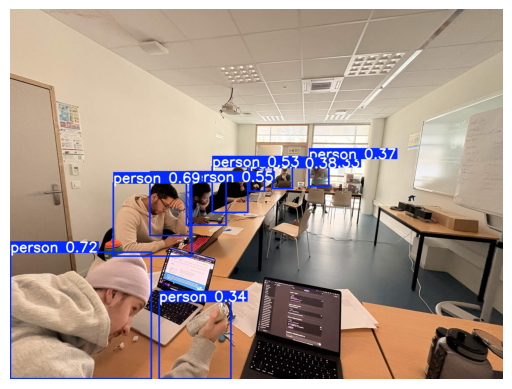

In [7]:
model = YOLO("yolo11n.pt")

# Load test image
img_path = "data/IMG_1780.jpg"

# Détection uniquement des personnes (classes=[0] = person dans COCO)
results = model.predict(img_path, classes=[0])

# Affichage de l'image avec uniquement les boxes personnes
annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
plt.imshow(annotated_rgb)
plt.axis('off')
plt.show()

In [8]:
boxes = results[0].boxes

count = 0

for box in boxes:
    cls = int(box.cls[0])

    if cls == 0:  # personne
        count += 1

print("Nombre de personnes :", count)

Nombre de personnes : 9


(np.float64(-0.5), np.float64(2879.5), np.float64(2159.5), np.float64(-0.5))

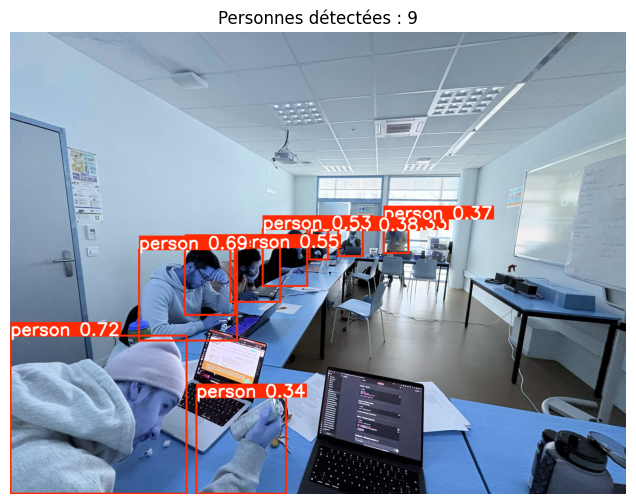

In [9]:
result_img = results[0].plot()

plt.figure(figsize=(8,6))
plt.imshow(result_img)
plt.title(f"Personnes détectées : {count}")
plt.axis("off")